<a href="https://colab.research.google.com/github/Daniela-Alves2004/data-mining/blob/main/Atividade_Pr%C3%A1tica_%E2%80%93_Pr%C3%A9_processamento_de_Dados_com_Scikit_Learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Pratica - Pre-processamento de Dados com Scikit-Learn



### Justificativa de Limpeza e Seleção

O atributo customerID foi removido por ser apenas um identificador único de cada cliente. Como ele não representa uma característica relacionada ao comportamento ou ao perfil dos clientes, não contribui para a predição da variável alvo (Churn) e pode ser descartado sem prejuízo para o modelo.

### Sobre o Data Leakage
O **Data Leakage** (vazamento de dados) ocorre quando informações do conjunto de teste 'vazam' para o treino durante o pré-processamento (como ao calcular a média global para imputação ou o desvio padrão para normalização). Para evitar isso, os transformadores foram ajustados (`fit`) apenas com os dados de treinamento. O conjunto de teste foi apenas transformado, garantindo que o modelo seja avaliado em dados verdadeiramente inéditos, simulando o cenário real de predição.

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder


In [ ]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 1. Análise Inicial dos Dados
Realize uma análise exploratória básica contendo:



* Quantidade de registros e atributos;
* Tipos de dados presentes na base;
* Quantidade de valores ausentes por atributo;
* Distribuição da variável alvo Churn.

In [79]:

print(f"Quantidade de registros: {df.shape[0]}")
print(f"Quantidade de atributos: {df.shape[1]}")


Quantidade de registros: 7043
Quantidade de atributos: 21


In [74]:
print("\nTipos de dados:")
display(df.dtypes)


Tipos de dados:


,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


In [80]:
df_proc = df.copy()

In [81]:
df_proc['TotalCharges'] = pd.to_numeric(df_proc['TotalCharges'], errors='coerce')

In [82]:

# Verificando valores ausentes
print("\nValores ausentes por atributo:")
print(df_proc.isnull().sum())




Valores ausentes por atributo:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


Churn
No     5174
Yes    1869
Name: count, dtype: int64


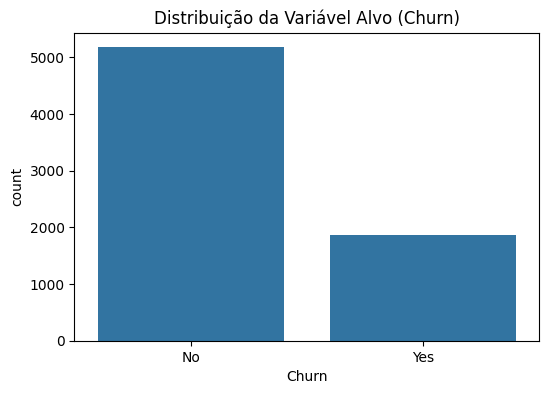

In [83]:
# Distribuição da variável alvo Churn

print(df_proc['Churn'].value_counts())
plt.show()
plt.figure(figsize=(6, 4))
sns.countplot(data=df_proc, x='Churn')
plt.title('Distribuição da Variável Alvo (Churn)')
plt.show()

## 2. Pré-processamento dos Dados

Utilizando a biblioteca Scikit-Learn, implemente:


*   Tratamento de valores ausentes: utilizar SimpleImputer para tratar atributos com valores faltantes.

*   Transformação de atributos categóricos: utilizar OneHotEncoder para atributos categóricos.
* Normalização: utilizar MinMaxScaler ou StandardScaler para atributos numéricos.
* Remoção de atributos irrelevantes: justificar a remoção de atributos que não contribuem para a predição, como identificadores, por exemplo.






In [84]:
# Remoção do identificador único (ID)
df_proc = df_proc.drop(columns=['customerID'])

In [85]:

# Definindo X removendo apenas a variável alvo
X = df_proc.drop('Churn', axis=1)

# Usando LabelEncoder para transformar a variável alvo em numérica
y = LabelEncoder().fit_transform(df_proc['Churn'])

## 3. Separação dos Dados
Realize a divisão dos dados em:

* Treinamento: 80%
* Teste: 20%

Utilize a função:

```train_test_split()```


In [86]:
# Separação dos Dados (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y )


In [87]:
# Identificando colunas por tipo
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

In [88]:
# Tratamento de valores ausentes com SimpleImputer
imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')

# Ajustando e transformando o treino
X_train[numeric_features] = imputer_num.fit_transform(X_train[numeric_features])
X_train[categorical_features] = imputer_cat.fit_transform(X_train[categorical_features])

# Apenas transformando o teste (evitando Data Leakage)
X_test[numeric_features] = imputer_num.transform(X_test[numeric_features])
X_test[categorical_features] = imputer_cat.transform(X_test[categorical_features])

In [89]:
# Codificação de variáveis categóricas com OneHotEncoder
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Ajustando no treino
encoder.fit(X_train[categorical_features])

# Criando nomes de colunas e transformando
def transform_categorical(df_target, encoder_obj, cols):
    encoded_data = encoder_obj.transform(df_target[cols])
    encoded_df = pd.DataFrame(encoded_data, columns=encoder_obj.get_feature_names_out(cols), index=df_target.index)
    return pd.concat([df_target.drop(columns=cols), encoded_df], axis=1)

X_train_encoded = transform_categorical(X_train, encoder, categorical_features)
X_test_encoded = transform_categorical(X_test, encoder, categorical_features)

# Evitando Data Leakage

O pré-processamento deve ser realizado corretamente para evitar vazamento de dados.

Portanto:

* Os transformadores SimpleImputer, OneHotEncoder e Scaler devem ser ajustados com fit apenas no conjunto de treinamento;
* O conjunto de teste deve utilizar apenas a transformação com transform, gerada a partir do conjunto de treinamento;
* Explique brevemente no relatório o que é Data Leakage e por que ele deve ser evitado.

In [90]:
# Normalização com StandardScaler
scaler = StandardScaler()

# Ajustando no treino e transformando ambos
X_train_transformed = scaler.fit_transform(X_train_encoded)
X_test_transformed = scaler.transform(X_test_encoded)


In [91]:
# Verificação final dos dados prontos para o modelo
print(f"Shape Final Treino: {X_train_transformed.shape}")
print(f"Shape Final Teste: {X_test_transformed.shape}")

Shape Final Treino: (5634, 30)
Shape Final Teste: (1409, 30)


# 5. Construção do Modelo
Treine um modelo utilizando:
 * DecisionTreeClassifier - Avalie o modelo utilizando:
      * Relatório de Classificação, contendo Precision, Recall e F1-Score.


In [92]:
# O modelo deve ser treinado com os dados que passaram pelo preprocessor
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_transformed, y_train)

# Predições utilizando o conjunto de teste transformado
y_pred = clf.predict(X_test_transformed)

In [93]:


# Avaliação
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))



Relatório de Classificação:
              precision    recall  f1-score   support

    No Churn       0.82      0.80      0.81      1035
       Churn       0.49      0.53      0.51       374

    accuracy                           0.73      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.73      0.73      0.73      1409

